### Apply RAG using Langchain and OpenAI to all fund prospectus

In [2]:
!pip install openai
!pip install langchain
!pip install langchain-chroma
!pip install -U langchain-community
!pip install tiktoken
!pip install unstructured
!pip install --upgrade --force-reinstall pandas scipy numba


[notice] A new release of pip is available: 23.0.1 -> 25.1
[notice] To update, run: C:\Users\Jennifer Langley\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 25.1
[notice] To update, run: C:\Users\Jennifer Langley\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 25.1
[notice] To update, run: C:\Users\Jennifer Langley\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 25.1
[notice] To update, run: C:\Users\Jennifer Langley\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 25.1
[notice] To update, run: C:\Users\Jennifer Langley\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 25.1
[notice] To update, run: C:\Users\Jennifer Langley\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


  Using cached pandas-2.2.3-cp310-cp310-win_amd64.whl (11.6 MB)
  Using cached scipy-1.15.2-cp310-cp310-win_amd64.whl (41.2 MB)
  Using cached numba-0.61.2-cp310-cp310-win_amd64.whl (2.8 MB)
  Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)
  Using cached numpy-2.2.5-cp310-cp310-win_amd64.whl (12.9 MB)
  Using cached llvmlite-0.44.0-cp310-cp310-win_amd64.whl (30.3 MB)
  Using cached six-1.17.0-py2.py3-none-any.whl (11 kB)
  Attempting uninstall: pytz
    Found existing installation: pytz 2025.2
    Uninstalling pytz-2025.2:
      Successfully uninstalled pytz-2025.2
  Attempting uninstall: tzdata
    Found existing installation: tzdata 2025.2
    Uninstalling tzdata-2025.2:
      Successfully uninstalled tzdata-2025.2
  Attempting uninstall: six
    Found existing installation: six 1.17.0
    Uninstalling six-1.17.0:
      Successfully uninstalled s

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.2.5 which is incompatible.
tensorflow-intel 2.18.0 requires ml-dtypes<0.5.0,>=0.4.0, but you have ml-dtypes 0.5.1 which is incompatible.
tensorflow-intel 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.5 which is incompatible.
tensorflow-intel 2.18.0 requires tensorboard<2.19,>=2.18, but you have tensorboard 2.19.0 which is incompatible.
pygam 0.9.1 requires scipy<1.12,>=1.11.1; python_version >= "3.9" and python_version < "3.13", but you have scipy 1.15.2 which is incompatible.

[notice] A new release of pip is available: 23.0.1 -> 25.1
[notice] To update, run: C:\Users\Jennifer Langley\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [8]:
import numpy as np
import pandas as pd
import os
import openai
import sys
from IPython.display import HTML

In [30]:
from dotenv import load_dotenv
import os

# Load environment variables from the .env file
load_dotenv()

# Access the OpenAI API key from the environment variables
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')

In [9]:
# Utility functions
# Progress bar
def progress(value, max=100):
    return HTML("""
        <progress
            value='{value}'
            max='{max}',
            style='width: 100%'
        >
            {value}
        </progress>
    """.format(value=value, max=max))

# Save a word2vec dictionary.
def save_word2vec(filename):
    with open(os.path.join('./', filename),'a' , encoding='utf-8') as f :
        for k, v in word2vec.items():
            line = k+' '+str(list(v)).strip('[]').replace(',','')+'\n'
            f.write(line)

# Load a word2vec dictionary.
def load_word2vec(filename):
    word2vec = {}
    with open(os.path.join('./', filename), encoding='utf8') as f:
        for line in f:
            try :
                values = line.split()
                word = values[0]
                vec = np.asarray(values[1:], dtype='float32')
                word2vec[word] = vec
            except :
                None
    return word2vec

# read the repo in PATH and append the texts in a list
def get_data(PATH):
    list_dir = os.listdir(PATH)
    texts = []
    fund_names = []
    out = display(progress(0, len(list_dir)-1), display_id=True)
    for ii, filename in enumerate(list_dir) :
        with open(PATH+'/'+filename, 'r', encoding="utf8") as f :
            txt = f.read()
            try :
                txt_split = txt.split('<head_breaker>')
                summary = txt_split[1].strip()
                fund_name = txt_split[0].strip()
            except :
                summary = txt
                fund_name = ''
        texts.append(summary)
        fund_names.append(fund_name)
        out.update(progress(ii, len(list_dir)-1))
    return fund_names, texts

In [10]:
# Get the summaries
SUMMARY_PATH = './MutualFundSummary'
fund_names, summaries = get_data(SUMMARY_PATH)

In [11]:
SUMMARY_LABELS_PATH = './MutualFundLabels.csv'

df_extraction = pd.DataFrame({'fund_name' : fund_names})
df_label = pd.read_csv(SUMMARY_LABELS_PATH)
valid_classes = [
    'Balanced Fund (Low Risk)',
    'Equity Long Only (Low Risk)',
    'Fixed Income Long Only (Low Risk)'
]

# Filter out everything that's not one of the 3 valid classes
df_label = df_label[df_label['Investment Strategy'].isin(valid_classes)].reset_index(drop=True)

In [ ]:
from langchain.document_loaders import DirectoryLoader

# Load documents from a directory
loader = DirectoryLoader(path="./MutualFundSummary", glob="*.txt")

# Load the text data from the directory
documents = loader.load()

In [ ]:
from langchain.text_splitter import RecursiveCharacterTextSplitter, CharacterTextSplitter
from langchain_chroma import Chroma
from langchain.vectorstores import Chroma
from langchain.embeddings.openai import OpenAIEmbeddings
embedding = OpenAIEmbeddings()
persist_directory = './docs/chroma'

#llm_name = "gpt-3.5-turbo"
llm_name = "gpt-4o-mini"
print(llm_name)

from langchain.chat_models import ChatOpenAI
llm = ChatOpenAI(model_name=llm_name, temperature=0)
from langchain.chains import RetrievalQA

<ipython-input-17-3c6cfdc9e864>:5: LangChainDeprecationWarning: The class `OpenAIEmbeddings` was deprecated in LangChain 0.0.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import OpenAIEmbeddings``.
  embedding = OpenAIEmbeddings()


gpt-4o-mini


<ipython-input-17-3c6cfdc9e864>:13: LangChainDeprecationWarning: The class `ChatOpenAI` was deprecated in LangChain 0.0.10 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import ChatOpenAI``.
  llm = ChatOpenAI(model_name=llm_name, temperature=0)


In [12]:
r_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=100,
    separators=["\n\n", "\n", "(?<=\. )", " "]
)

NameError: name 'RecursiveCharacterTextSplitter' is not defined

In [ ]:
#splits=r_splitter.split_documents(documents)
ii = 4

splits=r_splitter.split_documents([documents[ii]])

fund_name = fund_names[ii]

persist_directory = f"./docs/chroma/{fund_name}"

vectordb = Chroma.from_documents(
  documents=splits,
  embedding=embedding,
  persist_directory=persist_directory
)

vectordb.persist()

print(len(vectordb))

561


<ipython-input-19-07a203268840>:16: LangChainDeprecationWarning: Since Chroma 0.4.x the manual persistence method is no longer supported as docs are automatically persisted.
  vectordb.persist()


In [ ]:
df_RAG = pd.DataFrame(fund_names, columns=['fund_name'])
df_RAG['Predicted strategy'] = np.nan
df_RAG['strategy evidence'] = np.nan
df_RAG['source meta data'] = np.nan

In [ ]:
from langchain.prompts import PromptTemplate

for ii in range(len(df_RAG)):
    print(ii)

    fund_name = df_RAG.iloc[ii]['fund_name']
    print(fund_name)

    splits = r_splitter.split_documents([documents[ii]])

    persist_directory = f"./docs/chroma/{fund_name}"

    vectordb = Chroma.from_documents(
        documents=splits,
        embedding=embedding,
        persist_directory=persist_directory
    )

    vectordb.persist()
    print(len(vectordb))

    # Build prompt
    template = """Use the following pieces of context to answer the question at the end.
             Choose only one of the following options as your answer:
             Balanced Fund (Low Risk)
             Fixed Income Long Only (Low Risk)
             Equity Long Only (Low Risk)
             Even if you are uncertain, you must choose the most likely option.

             {context}

             Question: Based on the prospectus, which category best describes the fund's investment strategy?

             Answer:
           """
    QA_CHAIN_PROMPT = PromptTemplate.from_template(template)

    qa_chain = RetrievalQA.from_chain_type(
        llm,
        retriever=vectordb.as_retriever(),
        return_source_documents=True,
        chain_type_kwargs={"prompt": QA_CHAIN_PROMPT}
    )

    # Use the template
    result = qa_chain({"query": f"Based on the prospectus for {fund_name}, which category best describes the fund’s investment strategy?"})

    # Storing results
    df_RAG.iloc[ii, 1] = result["result"]
    df_RAG.iloc[ii, 2] = result["source_documents"][0].page_content
    df_RAG.iloc[ii, 3] = str(result["source_documents"][0].metadata)


0
AB Balanced Wealth Strategy Portfolio
330


<ipython-input-21-fd49865e6718>:46: LangChainDeprecationWarning: The method `Chain.__call__` was deprecated in langchain 0.1.0 and will be removed in 1.0. Use :meth:`~invoke` instead.
  result = qa_chain({"query": f"Based on the prospectus for {fund_name}, which category best describes the fund’s investment strategy?"})
<ipython-input-21-fd49865e6718>:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Balanced Fund (Low Risk)' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_RAG.iloc[ii, 1] = result["result"]
<ipython-input-21-fd49865e6718>:50: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'AB Balanced Wealth Strategy Portfolio <head_breaker>

AB VPS BALANCED WEALTH STRATEGY PORTFOLIO --------------------------------------------------------------------------------

INVESTMENT OBJE

1
AB Asia ex-Japan Equity Portfolio
341
2
AB All Market Income Portfolio
319
3
AB All Market Real Return Portfolio
418
4
AB Arizona Portfolio
594
5
AB Bond Inflation Strategy
341
6
AB Credit Long/Short Portfolio
341
7
AB Discovery Value Fund
297
8
AB Dynamic Asset Allocation Portfolio
297
9
AB FlexFee Core Opportunities Portfolio
264
10
AB FlexFee Emerging Markets Growth Portfolio
187
11
AB FlexFee International Strategic Core Portfolio
286
12
AB FlexFee Large Cap Growth Portfolio
264
13
AB Global Risk Allocation-Moderate Portfolio
286
14
AB Global Thematic Growth Portfolio
187
15
AB Income Fund
310
16
AB Intermediate Bond Portfolio
320
17
AB Limited Duration High Income Portfolio
300
18
AB Massachusetts Portfolio
360
19
AB Minnesota Portfolio
330
20
AB Municipal Bond Inflation Strategy
290
21
AB New Jersey Portfolio
340
22
AB New York Portfolio
315
23
AB Pennsylvania Portfolio
306
24
AB Real Estate Investment Portfolio
306
25
AB Small Cap Value Portfolio
207
26
AB Small/Mid Cap Value 

In [ ]:
pd.set_option('display.max_colwidth', None)

In [ ]:
df_RAG.to_csv('./df_RAG_results.csv', index=False)


### Run locally starting here

In [13]:
### Loading from csv to run locally
import pandas as pd
df_RAG = pd.read_csv('./df_RAG_results.csv')

In [14]:
df_summary = df_label.merge(df_RAG, on='fund_name', how='inner')
df_summary.columns

Index(['id', 'fund_name', 'Performance fee?', 'Investment Strategy',
       'Leverage?', 'Portfolio composition', ' Concentration',
       'Predicted strategy', 'strategy evidence', 'source meta data'],
      dtype='object')

In [15]:
df2 = df_summary.dropna(subset = ['Investment Strategy', 'Predicted strategy'])
df2.columns

Index(['id', 'fund_name', 'Performance fee?', 'Investment Strategy',
       'Leverage?', 'Portfolio composition', ' Concentration',
       'Predicted strategy', 'strategy evidence', 'source meta data'],
      dtype='object')

In [16]:
y_true = df2['Investment Strategy']
y_pred = df2['Predicted strategy']
print(sorted(set(y_true)))
print(sorted(set(y_pred)))


['Balanced Fund (Low Risk)', 'Equity Long Only (Low Risk)', 'Fixed Income Long Only (Low Risk)']
['Balanced Fund (Low Risk)', 'Equity Long Only (Low Risk)', 'Fixed Income Long Only (Low Risk)']


In [17]:
from sklearn.metrics import confusion_matrix
# Define the order of labels for the confusion matrix
class_labels = [
    "Balanced Fund (Low Risk)",
    "Fixed Income Long Only (Low Risk)",
    "Equity Long Only (Low Risk)"
]

cm = confusion_matrix(df2['Investment Strategy'], df2['Predicted strategy'], labels=class_labels)
print(cm)

[[ 83   0   1]
 [ 24  99   7]
 [ 55   1 191]]


In [18]:
print(sorted(set(y_true)))
print(sorted(set(y_pred)))

['Balanced Fund (Low Risk)', 'Equity Long Only (Low Risk)', 'Fixed Income Long Only (Low Risk)']
['Balanced Fund (Low Risk)', 'Equity Long Only (Low Risk)', 'Fixed Income Long Only (Low Risk)']


In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_labels))

                                   precision    recall  f1-score   support

         Balanced Fund (Low Risk)       0.51      0.99      0.67        84
Fixed Income Long Only (Low Risk)       0.96      0.77      0.86       247
      Equity Long Only (Low Risk)       0.99      0.76      0.86       130

                         accuracy                           0.81       461
                        macro avg       0.82      0.84      0.80       461
                     weighted avg       0.89      0.81      0.82       461



In [20]:
len(df2['Investment Strategy']) == len(df2['Predicted strategy'])

True

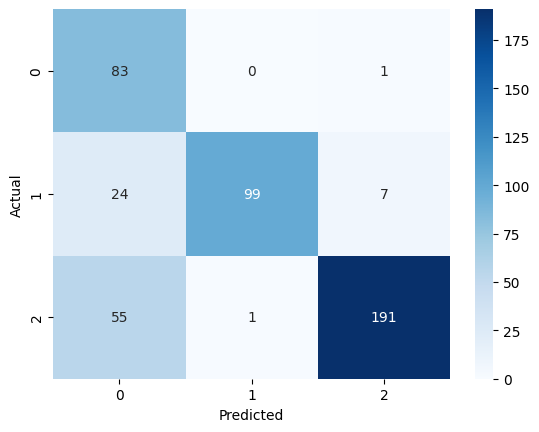

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [22]:
df2.columns

Index(['id', 'fund_name', 'Performance fee?', 'Investment Strategy',
       'Leverage?', 'Portfolio composition', ' Concentration',
       'Predicted strategy', 'strategy evidence', 'source meta data'],
      dtype='object')

In [23]:
df_RAG['fund_summary'] = summaries  # Adds the input texts
X = df_RAG['fund_summary'].values
y = df_RAG['Predicted strategy'].values

### Training classification algorithm

In [44]:
df_RAG_clean = df_RAG.dropna(subset=['fund_summary', 'Predicted strategy'])
X = df_RAG_clean['fund_summary'].values
y = df_RAG_clean['Predicted strategy'].values

# Now split
from sklearn.model_selection import train_test_split

# test set
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# validation set
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)


In [45]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize
import collections
import random
import time
import string
import re

[nltk_data] Downloading package stopwords to C:\Users\Jennifer
[nltk_data]     Langley\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Jennifer
[nltk_data]     Langley\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Jennifer
[nltk_data]     Langley\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [50]:
import nltk
import os

# Create a directory for NLTK data in your current working directory
os.makedirs('./nltk_data', exist_ok=True)

# Download the necessary data to that directory
nltk.download('punkt', download_dir='./nltk_data')
nltk.download('stopwords', download_dir='./nltk_data')

# Explicitly add this path to NLTK's search paths
nltk.data.path.insert(0, './nltk_data')

# Verify the data is available
print(f"NLTK data paths: {nltk.data.path}")
print(f"Is punkt available? {nltk.data.find('tokenizers/punkt')}")
print(f"Is stopwords available? {nltk.data.find('corpora/stopwords')}")

[nltk_data] Downloading package punkt to ./nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to ./nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


NLTK data paths: ['./nltk_data', 'C:\\Users\\Jennifer Langley/nltk_data', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\\nltk_data', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\\share\\nltk_data', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\\lib\\nltk_data', 'C:\\Users\\Jennifer Langley\\AppData\\Roaming\\nltk_data', 'C:\\nltk_data', 'D:\\nltk_data', 'E:\\nltk_data', 'C:/Users/Jennifer Langley/nltk_data', 'C:/Users/Jennifer Langley/nltk_data', 'C:/Users/Jennifer Langley/AppData/Roaming/nltk_data', 'C:/Users/Jennifer Langley/AppData/Roaming/nltk_data']
Is punkt available? c:\Users\Jennifer Langley\Documents\MSMFT 2024-2026\Spring 2025\MF 815 Machine Learning\mutual-fund-classification\nltk_data\tokenizers\punkt
Is stopwords available? c:\Users\Jennifer Langley\Documents\MSMFT 2024-2026\Spring 2025\MF 815 Machine Learning

In [ ]:
import nltk
import numpy as np
import re
import os
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Set the path to your local NLTK data directory
# Replace './nltk_data' with the actual path where you downloaded the data
nltk_data_path = './nltk_data'  # or the specific path you used
nltk.data.path.insert(0, nltk_data_path)

# Verify data availability (optional but helpful for debugging)
print(f"NLTK data paths: {nltk.data.path}")

# Initialize stop words
stop_words = set(stopwords.words('english')+list(string.punctuation)+['``',"''"]+["]","[","*"]+['doe', 'ha', 'wa'])

# Clean and tokenize the text with error handling
def tokenizer(txt):
    try:
        txt = str(txt).replace('\n', ' ').replace('\t', ' ').lower()
        word_tokens = word_tokenize(txt)
        filtered_sentence = [w for w in word_tokens if not w in stop_words]
        filtered_sentence = [w for w in filtered_sentence if re.sub("[^A-Za-z ]+",'',w) != '']
        return filtered_sentence
    except Exception as e:
        print(f"Error in tokenization: {e}")
        # Fallback to simpler tokenization
        txt = str(txt).replace('\n', ' ').replace('\t', ' ').lower()
        for punct in string.punctuation:
            txt = txt.replace(punct, ' ')
        words = txt.split()
        filtered_words = [w for w in words if w not in stop_words and w.strip() != '']
        filtered_words = [w for w in filtered_words if re.sub("[^A-Za-z]+",'',w) != '']
        return filtered_words

# Apply the tokenizer to your data - using a safer approach
try:
    text_words = np.concatenate([tokenizer(summary) for summary in X_train])
    print(text_words[:20])
except Exception as e:
    print(f"Error during concatenation: {e}")
    # Alternative approach that's more explicit about errors
    all_tokens = []
    for i, summary in enumerate(X_train):
        try:
            tokens = tokenizer(summary)
            all_tokens.extend(tokens)
        except Exception as e:
            print(f"Skipping item {i} due to: {e}")

    text_words = np.array(all_tokens)
    print(text_words[:20])

NLTK data paths: ['./nltk_data', './nltk_data', './nltk_data', 'C:\\Users\\Jennifer Langley/nltk_data', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\\nltk_data', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\\share\\nltk_data', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\\lib\\nltk_data', 'C:\\Users\\Jennifer Langley\\AppData\\Roaming\\nltk_data', 'C:\\nltk_data', 'D:\\nltk_data', 'E:\\nltk_data', 'C:/Users/Jennifer Langley/nltk_data', 'C:/Users/Jennifer Langley/nltk_data', 'C:/Users/Jennifer Langley/AppData/Roaming/nltk_data', 'C:/Users/Jennifer Langley/AppData/Roaming/nltk_data']
Error in tokenization: 
**********************************************************************
  Resource punkt_tab not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('punkt_tab')
  
  Fo

In [53]:
# Training Parameters
batch_size = 128 # The model will be trained batch per batch and one batch contains 128 rows
num_epochs = 2 # The model will go through all the data twice
# Word2Vec Parameters
embedding_size = 50 # Dimension of the embedding vector
max_vocabulary_size = 5000 # Total number of different words in the vocabulary
min_occurrence = 10 # Remove all words that does not appears at least n times
skip_window = 3 # How many words to consider left and right
num_skips = 4 # How many times to reuse an input to generate a label

# Build the dictionary and replace rare words with UNK token
count = [('UNK', -1)]
# Retrieve the most common words
count.extend(collections.Counter(text_words).most_common(max_vocabulary_size - 1))
# Remove samples with less than 'min_occurrence' occurrences
for i in range(len(count) - 1, -1, -1):
    if count[i][1] < min_occurrence:
        count.pop(i)
    else:
        # The collection is ordered, so stop when 'min_occurrence' is reached
        break


word2id = dict()
for i, (word, _)in enumerate(count):
    word2id[word] = i
id2word = dict(zip(word2id.values(), word2id.keys()))
vocab_size = len(id2word)

# create data
data = list()
unk_count = 0
for word in text_words:
    # Retrieve a word id, or assign it index 0 ('UNK') if not in dictionary
    index = word2id.get(word, 0)
    if index == 0:
        unk_count += 1
    data.append(index)
count[0] = ('UNK', unk_count)

In [54]:
# build OneHot vector from index
def to_one_hot(data_point_index, vocab_size):
    temp = np.zeros(vocab_size)
    temp[data_point_index] = 1
    return temp

# Generate training batch for the skip-gram model
def batch_generator(batch_size, num_skips, skip_window, vocab_size):
    data_index = 0
    while True :
        assert batch_size % num_skips == 0
        assert num_skips <= 2 * skip_window
        # batch is filled with 128 inputs
        batch = np.ndarray(shape=(batch_size), dtype=np.int32)
        # labels is filled with 128 outputs
        labels = np.ndarray(shape=(batch_size), dtype=np.int32)
        span = 2 * skip_window + 1
        # buffer keep track of the visited indexes visited
        buffer = collections.deque(maxlen=span)
        if data_index + span > len(data):
            data_index = 0
            # We stop the loop when we went through all the corpus
            break
        buffer.extend(data[data_index:data_index + span])
        data_index += span
        for i in range(batch_size // num_skips):
            # Take the context current word
            context_words = [w for w in range(span) if w != skip_window]
            # Randomly select num_skips words in the context
            words_to_use = random.sample(context_words, num_skips)
            for j, context_word in enumerate(words_to_use):
                # Creates one raw data
                batch[i * num_skips + j] = buffer[skip_window]
                labels[i * num_skips + j] = buffer[context_word]
            if data_index == len(data):
                buffer.extend(data[0:span])
                data_index = span
            else:
                buffer.append(data[data_index])
                data_index += 1
        # Backtrack a little bit to avoid skipping words in the end of a batch
        data_index = (data_index + len(data) - span) % len(data)

        # translate word index to on-hot representation
        batch_one_hot = np.array([to_one_hot(b, vocab_size) for b in batch])
        labels_one_hot = np.array([to_one_hot(l, vocab_size) for l in labels])

        # output one batch
        yield batch_one_hot, labels_one_hot

In [ ]:
# Train skip-gram model
# Create en compile the Autoencoder
def create_word2vec_model():
    input_word = Input(shape=(vocab_size,))

    encoded = Dense(embedding_size, activation='linear')(input_word)
    decoded = Dense(vocab_size, activation='softmax')(encoded)

    autoencoder = Model(input_word, decoded)
    encoder = Model(input_word, encoded)

    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
    return encoder, autoencoder

In [ ]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# Create the model
encoder, autoencoder = create_word2vec_model()
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2855)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │       142,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2855)           │       145,605 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 288,405 (1.10 MB)

 Trainable params: 288,405 (1.10 MB)

 Non-trainable params: 0 (0.00 B)

In [57]:
from math import ceil
# Train the model by feeding it with our batch generator
autoencoder.fit(batch_generator(batch_size, num_skips, skip_window, vocab_size),
                steps_per_epoch=ceil(len(data) / batch_size),
                epochs=num_epochs)


Epoch 1/2
4504/4504 ━━━━━━━━━━━━━━━━━━━━ 92s 20ms/step - loss: 0.0796
Epoch 2/2
4504/4504 ━━━━━━━━━━━━━━━━━━━━ 79s 18ms/step - loss: 0.0027


In [82]:
# Create the Vectorizer function (prediciton of the encoder)
def vecotrize(word):
    word_one_hot = to_one_hot(word2id[word], vocab_size)
    return encoder.predict(np.array([word_one_hot]))[0]

# Create the word2vec dictionary
word2vec = {w : vecotrize(w) for w in word2id.keys()}

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━

In [83]:
our_word2vec = 'word2vec_perso.txt'
save_word2vec(our_word2vec)

In [76]:
# for a given word, output the n closer words in the word2vec maping.
from scipy.spatial.distance import cosine

def get_n_closer(w, n, word2vec):
    vect = word2vec[w]
    distances_dict = {k: cosine(v, vect) for k, v in word2vec.items()}

    closer_words = []
    for _ in range(n):
        min_key = min(distances_dict.keys(), key=lambda k: distances_dict[k])
        closer_words.append(min_key)
        del distances_dict[min_key]
    return closer_words

words_neighbors_1 = get_n_closer('expenses', 10, word2vec)
print('words close to expenses : ' +str(', '.join(words_neighbors_1)))
words_neighbors_2 = get_n_closer('derivatives', 10, word2vec)
print('words close to derivatives : ' +str(', '.join(words_neighbors_2)))

words close to expenses : expenses, made, moves, compensation, redeems, established, calling, compares, funds’, judgments
words close to derivatives : derivatives, extension, laws, partnership, process, enter, subsidiary, vehicle, economically, extreme


#### Reduce word vectors to 2 dimensions

In [77]:
# fit the TSNE dimenstion reduction model
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
vectors = np.array([v for k, v in word2vec.items()])
words = np.array([k for k, v in word2vec.items()])
print(vectors.shape)

tsne_model = TSNE(perplexity=40, n_components=2, init='pca', n_iter=2500, random_state=23)
vectors = tsne_model.fit_transform(vectors)

print(vectors.shape)

(2855, 50)


C:\Users\Jennifer Langley\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


(2855, 2)


In [78]:
reduced_word2vec = {words[i] : list(vectors[i]) for i in range (len(vectors))}

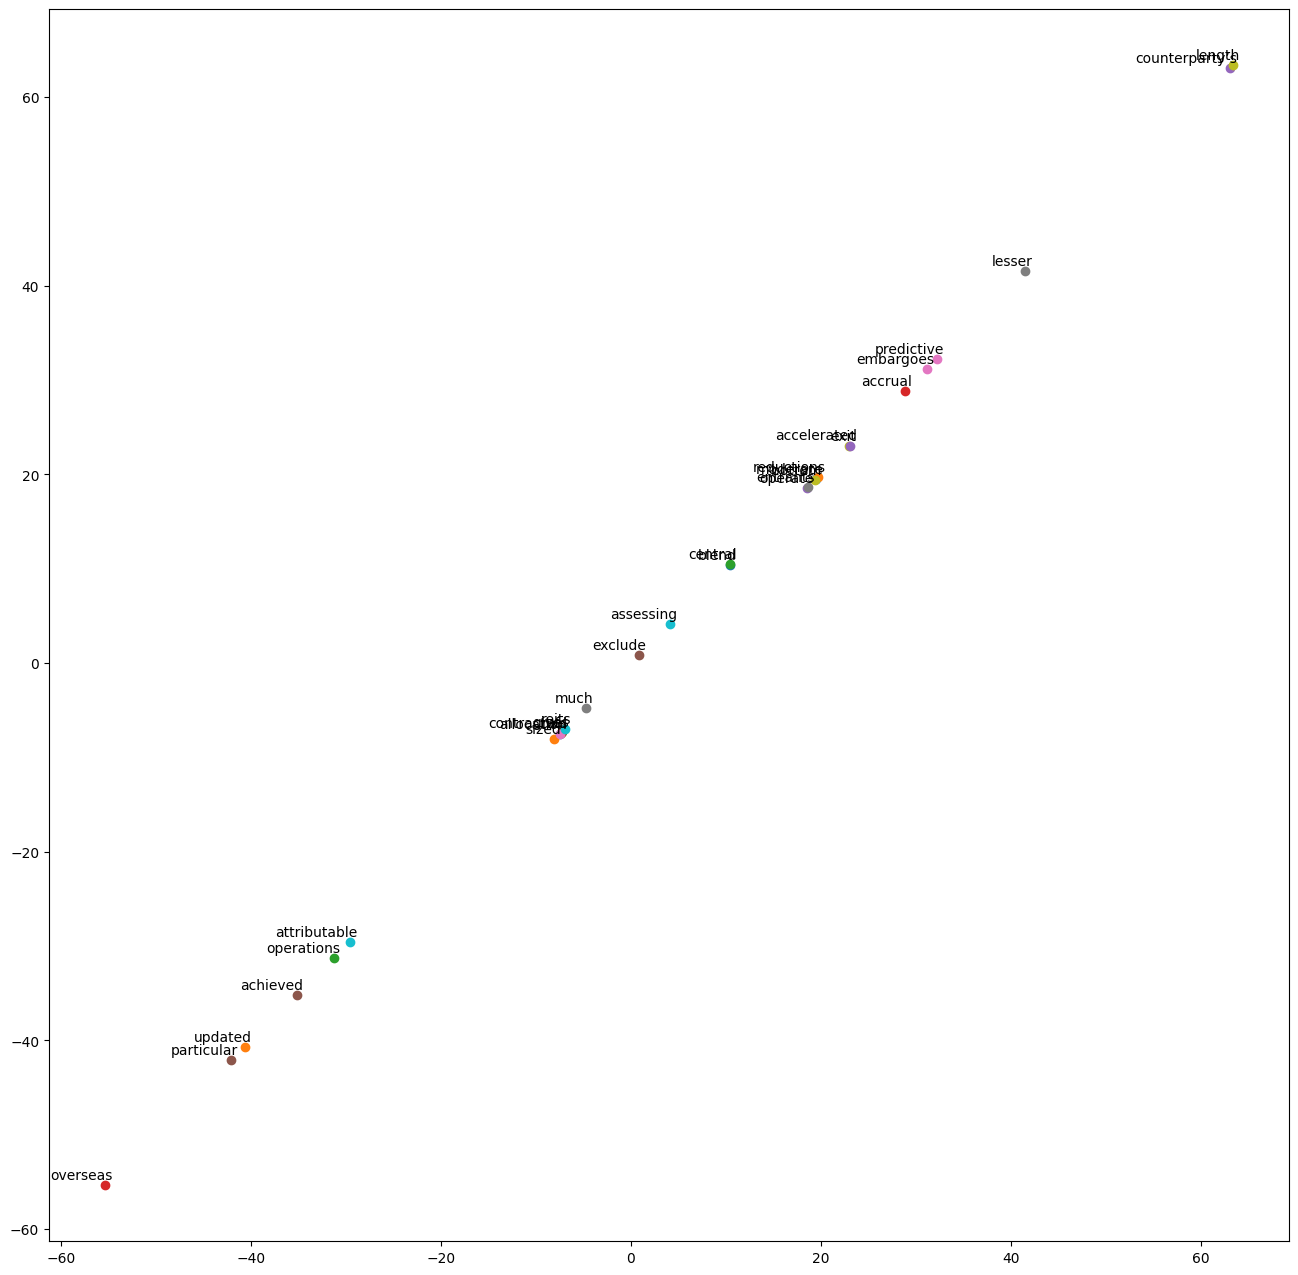

In [89]:
def create_neighbors_visualisation_data(words, num_neighbors, word2vec):
    words_neighbors = []
    for word in words :
        try :
            words_neighbors.append(get_n_closer(word, num_neighbors, word2vec))
        except :
            print(word +' not in word2vec')

    words_neighbors = np.concatenate(words_neighbors)
    vectors_neighbors = np.array([reduced_word2vec[word] for word in words_neighbors])

    return vectors_neighbors[:,0], vectors_neighbors[:,0], words_neighbors
# Fixed Income Fund
#x, y, labels = create_neighbors_visualisation_data(['bond', 'interest', 'duration'], 10, word2vec)

# Equity Long only Fund
# x, y, labels = create_neighbors_visualisation_data(['stock', 'equity', 'dividend'], 10, word2vec)

# Balanced Fund
x, y, labels = create_neighbors_visualisation_data(['allocation', 'blend', 'moderate'], 10, word2vec)


plt.figure(figsize=(16, 16))
for i in range(len(x)):
    plt.scatter(x[i],y[i])
    plt.annotate(labels[i],
        xy=(x[i], y[i]),
        xytext=(5, 2),
        textcoords='offset points',
        ha='right',
        va='bottom')
plt.show()

#### Build strategy knowledge bases

In [90]:
df_RAG.columns

Index(['fund_name', 'Predicted strategy', 'strategy evidence',
       'source meta data', 'fund_summary'],
      dtype='object')

In [91]:
from scipy.spatial.distance import cosine

def measure_distance_to_knowledge_base(summary, knowledge_bases, word2vec, embedding_size=50):
    # Tokenize and compute the sentence's centroid
    tokens = tokenizer(summary)
    sentence_barycentre = np.zeros(embedding_size)
    effective_len = 0
    for token in tokens:
        if token in word2vec:
            sentence_barycentre += np.array(word2vec[token])
            effective_len += 1

    # Prevent division by zero if no valid words are found
    if effective_len > 0:
        sentence_barycentre = sentence_barycentre / effective_len
    else:
        return {strategy: float('inf') for strategy in knowledge_bases}  # If no valid tokens, return infinities

    # Compute the cosine distance between the sentence barycentre and each knowledge base
    distances = {}
    for strategy, knowledge in knowledge_bases.items():
        distances[strategy] = cosine(sentence_barycentre, knowledge)  # Calculate distance

    return distances


In [99]:
import numpy as np
from collections import defaultdict

df_RAG = df_RAG.dropna(subset=['Predicted strategy'])

# Build knowledge bases using only training data
grouped_tokens_train = defaultdict(list)
for summary, strategy in zip(X_train, y_train):
    tokens = tokenizer(summary)
    grouped_tokens_train[strategy].extend(tokens)

knowledge_bases = {}
for strategy, tokens in grouped_tokens_train.items():
    vectors = np.array([word2vec[word] for word in tokens if word in word2vec])
    if len(vectors) > 0:
        knowledge_bases[strategy] = np.mean(vectors, axis=0)

# Apply to test data
test_predictions = []
for summary in X_test:
    distances = measure_distance_to_knowledge_base(summary, knowledge_bases, word2vec)
    predicted_strategy = min(distances, key=distances.get)
    test_predictions.append(predicted_strategy)

# Evaluate
from sklearn.metrics import accuracy_score, confusion_matrix
accuracy = accuracy_score(y_test, test_predictions)
print(f"Test Accuracy: {accuracy:.3f}")

Error in tokenization: 
**********************************************************************
  Resource punkt_tab not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('punkt_tab')
  
  For more information see: https://www.nltk.org/data.html

  Attempted to load tokenizers/punkt_tab/english/

  Searched in:
    - './nltk_data'
    - './nltk_data'
    - './nltk_data'
    - 'C:\\Users\\Jennifer Langley/nltk_data'
    - 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\\nltk_data'
    - 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\\share\\nltk_data'
    - 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\\lib\\nltk_data'
    - 'C:\\Users\\Jennifer Langley\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
    - 'C:/Users/Jennifer Lang

In [100]:
for strategy, vec in knowledge_bases.items():
    print(f"Strategy: {strategy}, Vector shape: {vec.shape}")


Strategy: Fixed Income Long Only (Low Risk), Vector shape: (50,)
Strategy: Balanced Fund (Low Risk), Vector shape: (50,)
Strategy: Equity Long Only (Low Risk), Vector shape: (50,)


#### Cosine similarity

In [101]:
def extract_sentence_distance(summary, knowledge, n_closer, n_reject, num_sent):
    sentences = sent_tokenize(summary)
    sentence_scores = []

    for j, sentence in enumerate(sentences):
        tokens = tokenizer(sentence)

        sentence_barycentre = np.zeros(embedding_size)
        effective_len = 0

        for token in tokens :
            try :
                sentence_barycentre += np.array(word2vec[token])
                effective_len += 1
            except KeyError :
                pass
            except :
                raise

        # Reject sentences with less than n_reject words in our word2vec map
        if effective_len <= n_reject :
            sentence_scores.append(1)

        else :
            sentence_barycentre = sentence_barycentre/effective_len
            # Compute the distance sentece_barycentre -> words in our knowledge base
            barycentre_distance = [cosine(sentence_barycentre, word2vec[key_word]) for key_word in knowledge]
            barycentre_distance.sort()
            # Create the score of the sentence by averaging the "n_closer" smallest distances
            score = np.mean(barycentre_distance[:n_closer])
            sentence_scores.append(score)
    # Select the "num_sent" sentences that have the smallest score (smallest distance score with the knowledge base)
    sentence_scores, sentences = zip(*sorted(zip(sentence_scores, sentences)))
    top_sentences = sentences[:num_sent]
    return ' '.join(top_sentences)

In [102]:
# Apply to each summary in the DataFrame
for _, row in df_RAG.iterrows():
    summary = row['fund_summary']

    # Measure distance to each knowledge base
    distances = measure_distance_to_knowledge_base(summary, knowledge_bases, word2vec)

    # Find the strategy with the minimum distance
    predicted_strategy = min(distances, key=distances.get)

    # You can store the result in the dataframe or use it as needed
    print(f"Predicted strategy for '{row['fund_name']}': {predicted_strategy}")


Error in tokenization: 
**********************************************************************
  Resource punkt_tab not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('punkt_tab')
  
  For more information see: https://www.nltk.org/data.html

  Attempted to load tokenizers/punkt_tab/english/

  Searched in:
    - './nltk_data'
    - './nltk_data'
    - './nltk_data'
    - 'C:\\Users\\Jennifer Langley/nltk_data'
    - 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\\nltk_data'
    - 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\\share\\nltk_data'
    - 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\\lib\\nltk_data'
    - 'C:\\Users\\Jennifer Langley\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
    - 'C:/Users/Jennifer Lang

#### Predict and evaluate

In [103]:
df2.columns

Index(['id', 'fund_name', 'Performance fee?', 'Investment Strategy',
       'Leverage?', 'Portfolio composition', ' Concentration',
       'Predicted strategy', 'strategy evidence', 'source meta data'],
      dtype='object')

In [ ]:
# merge the true and predicted strategies into one aligned DataFrame
df_eval = df2[['fund_name', 'Investment Strategy']].merge(
    df_RAG[['fund_name', 'fund_summary']], on='fund_name', how='inner'
)

# Drop rows with missing data
df_eval = df_eval.dropna(subset=['fund_summary', 'Investment Strategy'])

# Predict strategies
# measure distance to each knowledge base and return the closest strategy
def get_closest_strategy(summary, knowledge_bases, word2vec):
    distances = measure_distance_to_knowledge_base(summary, knowledge_bases, word2vec)
    closest_strategy = min(distances.items(), key=lambda x: x[1])[0]
    return closest_strategy

df_eval['Predicted'] = df_eval['fund_summary'].apply(lambda summary: get_closest_strategy(summary, knowledge_bases, word2vec))


# compute accuracy
from sklearn.metrics import accuracy_score, confusion_matrix

y_true = df_eval['Investment Strategy']
y_pred = df_eval['Predicted']

accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy:.3f}")

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)


Error in tokenization: 
**********************************************************************
  Resource punkt_tab not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('punkt_tab')
  
  For more information see: https://www.nltk.org/data.html

  Attempted to load tokenizers/punkt_tab/english/

  Searched in:
    - './nltk_data'
    - './nltk_data'
    - './nltk_data'
    - 'C:\\Users\\Jennifer Langley/nltk_data'
    - 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\\nltk_data'
    - 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\\share\\nltk_data'
    - 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\\lib\\nltk_data'
    - 'C:\\Users\\Jennifer Langley\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
    - 'C:/Users/Jennifer Lang

#### Tune parameters

In [110]:
# Convert each summary to an average Word2Vec vector
def summary_to_vec(summary, word2vec, embedding_size=50):
    tokens = tokenizer(summary)
    vectors = [word2vec[token] for token in tokens if token in word2vec]
    return np.mean(vectors, axis=0) if vectors else np.zeros(embedding_size)

# Vectorize datasets
X_train_vecs = np.array([summary_to_vec(s, word2vec) for s in X_train])
X_val_vecs   = np.array([summary_to_vec(s, word2vec) for s in X_val])
X_test_vecs  = np.array([summary_to_vec(s, word2vec) for s in X_test])

Error in tokenization: 
**********************************************************************
  Resource punkt_tab not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('punkt_tab')
  
  For more information see: https://www.nltk.org/data.html

  Attempted to load tokenizers/punkt_tab/english/

  Searched in:
    - './nltk_data'
    - './nltk_data'
    - './nltk_data'
    - 'C:\\Users\\Jennifer Langley/nltk_data'
    - 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\\nltk_data'
    - 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\\share\\nltk_data'
    - 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\\lib\\nltk_data'
    - 'C:\\Users\\Jennifer Langley\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
    - 'C:/Users/Jennifer Lang

In [122]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_vecs_scaled = scaler.fit_transform(X_train_vecs)  # create temp scaled version
X_test_vecs_scaled = scaler.transform(X_test_vecs)        # same for test set

param_grid = {
    'C': [0.5, 1, 2],             # Narrow in around 1
    'gamma': ['scale', 0.05, 0.1, 0.2],  # Focus on small gamma tweaks
    'kernel': ['rbf'],            # Just stick with the winning kernel
}



classifierSVC = SVC()
grid_search = GridSearchCV(classifierSVC, param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search.fit(X_train_vecs_scaled, y_train)  # Fit using scaled temp data

print("Best Hyperparameters:", grid_search.best_params_)
y_pred_SVC = grid_search.best_estimator_.predict(X_test_vecs_scaled)

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_SVC)
print(cm)

print("Classification Report:")
print(classification_report(y_test, y_pred_SVC))


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Hyperparameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Confusion Matrix:
[[19 15  9]
 [ 2 41  1]
 [ 1  2 19]]
Classification Report:
                                   precision    recall  f1-score   support

         Balanced Fund (Low Risk)       0.86      0.44      0.58        43
      Equity Long Only (Low Risk)       0.71      0.93      0.80        44
Fixed Income Long Only (Low Risk)       0.66      0.86      0.75        22

                         accuracy                           0.72       109
                        macro avg       0.74      0.75      0.71       109
                     weighted avg       0.76      0.72      0.71       109



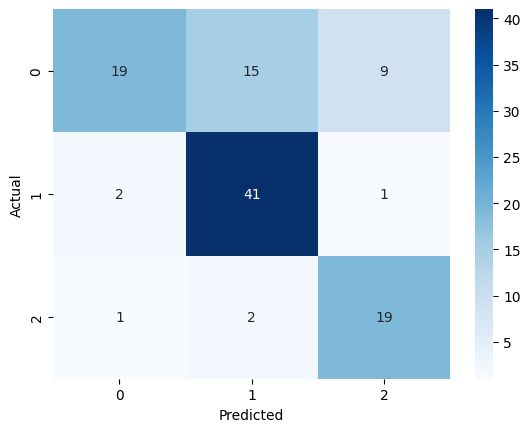

In [117]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Logistic regression

In [127]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report

# Define parameter grid
param_grid_logreg = {
    'C': [0.01, 0.1, 1, 10],              # Regularization strength
    'penalty': ['l2'],                    # Stick to l2 (l1 needs solver='liblinear')
    'solver': ['lbfgs'],                  # Good for multinomial, large datasets
    'max_iter': [200]                     # Ensure convergence
}

# Create Logistic Regression model
logreg = LogisticRegression(multi_class='auto')

# Run GridSearchCV
grid_logreg = GridSearchCV(logreg, param_grid_logreg, cv=3, n_jobs=-1, verbose=1)
grid_logreg.fit(X_train_vecs, y_train)

# Best model
print("Best Hyperparameters:", grid_logreg.best_params_)

# Predict
y_pred_logreg = grid_logreg.best_estimator_.predict(X_test_vecs)

# Evaluation
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
print("Confusion Matrix:\n", cm_logreg)
print("Classification Report:\n", classification_report(y_test, y_pred_logreg))


Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best Hyperparameters: {'C': 0.01, 'max_iter': 200, 'penalty': 'l2', 'solver': 'lbfgs'}
Confusion Matrix:
 [[ 0 43  0]
 [ 0 44  0]
 [ 0 22  0]]
Classification Report:
                                    precision    recall  f1-score   support

         Balanced Fund (Low Risk)       0.00      0.00      0.00        43
      Equity Long Only (Low Risk)       0.40      1.00      0.58        44
Fixed Income Long Only (Low Risk)       0.00      0.00      0.00        22

                         accuracy                           0.40       109
                        macro avg       0.13      0.33      0.19       109
                     weighted avg       0.16      0.40      0.23       109



C:\Users\Jennifer Langley\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\Jennifer Langley\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Jennifer Langley\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classificat

### Naive Bayes

Confusion Matrix:
[[32  7  4]
 [21 23  0]
 [ 5  4 13]]

Classification Report:
                                   precision    recall  f1-score   support

         Balanced Fund (Low Risk)       0.55      0.74      0.63        43
      Equity Long Only (Low Risk)       0.68      0.52      0.59        44
Fixed Income Long Only (Low Risk)       0.76      0.59      0.67        22

                         accuracy                           0.62       109
                        macro avg       0.66      0.62      0.63       109
                     weighted avg       0.65      0.62      0.62       109



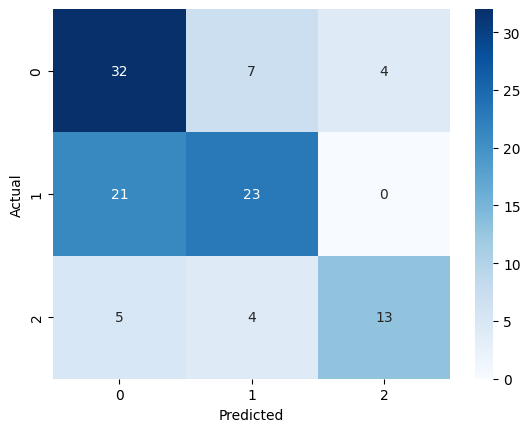

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

# Word2Vec vectorized summaries
X_train_nb = X_train_vecs
X_test_nb  = X_test_vecs

NB = GaussianNB()

# Fit
NB.fit(X_train_nb, y_train)

# Predict
y_pred_NB = NB.predict(X_test_nb)

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_NB))
cm = confusion_matrix(y_test, y_pred_NB)

# Performance Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_NB))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### SVC selected as best model

Fitting 3 folds for each of 84 candidates, totalling 252 fits
Best Hyperparameters: {'C': 1.0, 'class_weight': None, 'gamma': 'scale', 'kernel': 'rbf', 'probability': True}
Confusion Matrix:
[[19 15  9]
 [ 2 41  1]
 [ 1  2 19]]
Classification Report:
                                   precision    recall  f1-score   support

         Balanced Fund (Low Risk)       0.86      0.44      0.58        43
      Equity Long Only (Low Risk)       0.71      0.93      0.80        44
Fixed Income Long Only (Low Risk)       0.66      0.86      0.75        22

                         accuracy                           0.72       109
                        macro avg       0.74      0.75      0.71       109
                     weighted avg       0.76      0.72      0.71       109



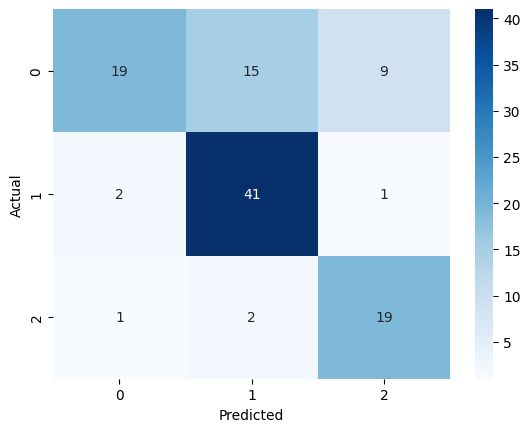

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_vecs_scaled = scaler.fit_transform(X_train_vecs)  # create temp scaled version
X_test_vecs_scaled = scaler.transform(X_test_vecs)        # same for test set

param_grid = {
    'C': [0.1, 0.5, 1.0, 2.0, 5.0, 10.0],  # Wider range
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.05, 0.1, 0.5],  # Detailed gamma exploration
    'kernel': ['rbf'],
    'class_weight': [None, 'balanced'],  # Test both weighting approaches
    'probability': [True]  # For comparable outputs with RAG
}

classifierSVC = SVC()
grid_search = GridSearchCV(classifierSVC, param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search.fit(X_train_vecs_scaled, y_train)  # Fit using scaled temp data

print("Best Hyperparameters:", grid_search.best_params_)
y_pred_SVC = grid_search.best_estimator_.predict(X_test_vecs_scaled)

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_SVC)
print(cm)

print("Classification Report:")
print(classification_report(y_test, y_pred_SVC))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
